# Derivatives Engine

## Monte Carlo Option Pricing, Black-Scholes Comparison, and Convergence Analysis

This notebook builds directly on the Week 1 quantitative foundation
(`week1_quant_foundations.ipynb`) and answers one central question:

> **How accurately can Monte Carlo simulation reproduce the Black-Scholes
> price of a European option, and how does accuracy improve as the
> number of simulations increases?**

**Benchmark scenario** (used throughout unless stated otherwise):

| Parameter | Value |
|---|---|
| Spot (S0) | $100 |
| Strike (K) | $100 |
| Risk-Free Rate (r) | 5% |
| Volatility (σ) | 20% |
| Maturity (T) | 1 year |
| Simulations (M) | 100,000 |
| Seed | 42 |


In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from app.models.option_parameters import OptionParameters, OptionSimulationConfig, OptionType

from app.quant.derivatives.payoffs import call_payoff, put_payoff, payoff
from app.quant.derivatives.black_scholes import black_scholes_call, black_scholes_put, black_scholes_price
from app.quant.derivatives.monte_carlo_pricer import (
    price_option_monte_carlo, simulate_risk_neutral_terminal_prices,
)
from app.quant.derivatives.pricing_error import compare_to_black_scholes, root_mean_squared_error
from app.quant.derivatives.convergence import option_convergence_study, estimate_convergence_rate
from app.quant.derivatives.validation import check_call_bounds, check_put_bounds, check_put_call_parity
from app.quant.derivatives.sensitivity import sweep_parameter
from app.quant.derivatives.reporting import generate_pricing_report, generate_paired_pricing_report

from app.visualization.option_payoff import plot_call_payoff, plot_put_payoff, plot_payoff_distribution
from app.visualization.pricing_convergence import plot_convergence_panel
from app.visualization.pricing_comparison import (
    plot_terminal_price_distribution, plot_mc_vs_bs_comparison,
    plot_error_across_moneyness, plot_error_across_volatility,
)

plt.rcParams["figure.figsize"] = (9, 6)

SPOT, STRIKE, RATE, VOL, MATURITY = 100.0, 100.0, 0.05, 0.20, 1.0
SEED = 42


## 1. Introduction — Why the Risk-Neutral Measure?

Week 1's GBM engine simulated an asset's *physical-measure* dynamics:
`dS_t = μS_t dt + σS_t dW_t`, where `μ` is the historical/expected
return — useful for forecasting or risk analysis of the actual asset.

**Option pricing is different.** No-arbitrage pricing theory shows that
if a derivative can be replicated by continuously trading the
underlying and a risk-free bond, its price does not depend on investors'
risk preferences or the asset's real-world expected return at all — it
depends only on the risk-free rate, `r`. This is the **risk-neutral
measure**: for pricing purposes, we simulate as if every asset drifted
at `r`, and discount expected payoffs at `r`.

```
dS_t = r S_t dt + σ S_t dW_t        (risk-neutral, used to PRICE)
dS_t = μ S_t dt + σ S_t dW_t        (physical, used to FORECAST)
```

Swapping `μ` for `r` is the single most important correction Week 2
makes relative to Week 1 — get this wrong and every downstream price is
wrong, even though the code looks almost identical.


## 2. Option Parameters

`OptionParameters` mirrors Week 1's `MarketParameters` but is
deliberately a separate model — it carries `risk_free_rate` as the
pricing drift, a `strike`, and an `OptionType`, and validates all of
these independently.


In [2]:
call_option = OptionParameters(SPOT, STRIKE, RATE, VOL, MATURITY, OptionType.CALL)
put_option = OptionParameters(SPOT, STRIKE, RATE, VOL, MATURITY, OptionType.PUT)
sim_config = OptionSimulationConfig(simulations=100_000, seed=SEED)

print(call_option)
print(put_option)
print(sim_config)
print(f"Moneyness (S0/K): {call_option.moneyness:.2f} -> {call_option.classify_moneyness()}")


OptionParameters(spot=100.0, strike=100.0, risk_free_rate=0.05, volatility=0.2, maturity=1.0, option_type=<OptionType.CALL: 'CALL'>)
OptionParameters(spot=100.0, strike=100.0, risk_free_rate=0.05, volatility=0.2, maturity=1.0, option_type=<OptionType.PUT: 'PUT'>)
OptionSimulationConfig(simulations=100000, seed=42)
Moneyness (S0/K): 1.00 -> ATM


## 3–4. European Call and Put Payoffs

```
C_T = max(S_T - K, 0)          P_T = max(K - S_T, 0)
```

Both are pure functions of the terminal price and strike — no pricing
model needed yet. They're vectorized (no Python loops) and reused by
the Monte Carlo pricer below.


In [3]:
s_t_grid = np.array([60, 80, 100, 120, 140], dtype=float)
print("S_T:          ", s_t_grid)
print("Call payoff:  ", call_payoff(s_t_grid, STRIKE))
print("Put payoff:   ", put_payoff(s_t_grid, STRIKE))


S_T:           [ 60.  80. 100. 120. 140.]
Call payoff:   [ 0.  0.  0. 20. 40.]
Put payoff:    [40. 20.  0.  0.  0.]


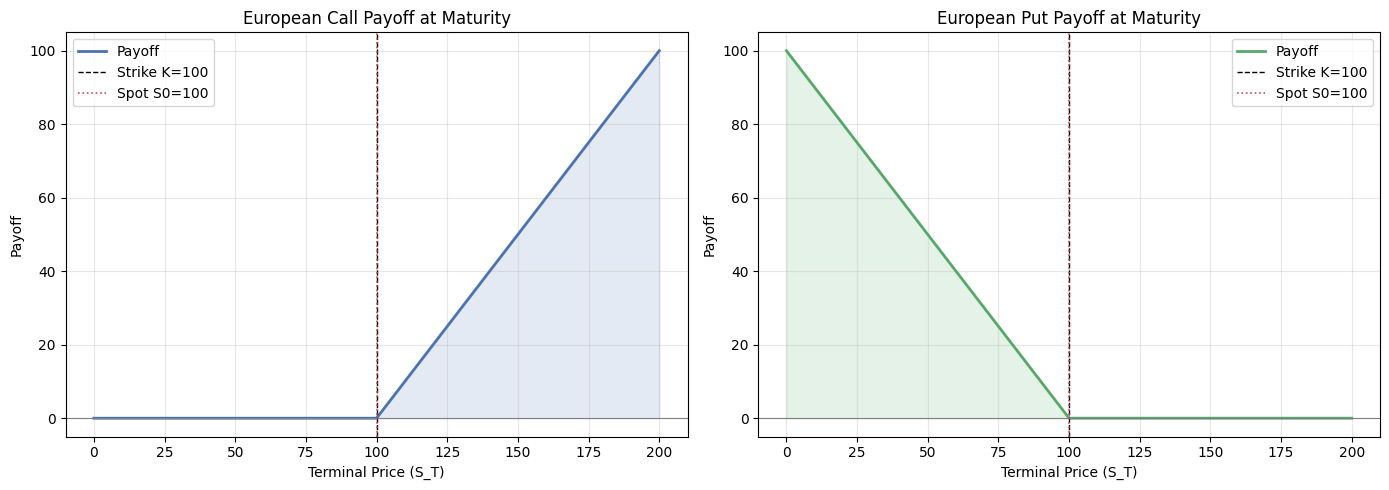

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_call_payoff(STRIKE, spot=SPOT, ax=axes[0])
plot_put_payoff(STRIKE, spot=SPOT, ax=axes[1])
fig.tight_layout()
plt.show()


## 5. Risk-Neutral GBM Simulation

`simulate_risk_neutral_terminal_prices` reuses Week 1's exact GBM
discretization

```
S_T = S0 · exp[(r − ½σ²)T + σ√T · Z],    Z ~ N(0,1)
```

but with `r` as the drift — never the historical `μ`. Because a
European option's payoff depends only on `S_T`, **full paths are never
generated**: this samples `S_T` directly (Week 1's terminal-only
shortcut), giving O(M) memory and time regardless of how many
"steps" a path-dependent option might eventually need.


In [5]:
terminal_prices = simulate_risk_neutral_terminal_prices(
    spot=SPOT, risk_free_rate=RATE, volatility=VOL, maturity=MATURITY,
    simulations=100_000, seed=SEED,
)
print(f"Simulated E[S_T]:     {terminal_prices.mean():.4f}")
print(f"Theoretical E[S_T]:   {SPOT * np.exp(RATE * MATURITY):.4f}  (= S0 * exp(r*T))")


Simulated E[S_T]:     105.0549
Theoretical E[S_T]:   105.1271  (= S0 * exp(r*T))


## 6–7. Monte Carlo Call and Put Pricing

In [6]:
call_result = price_option_monte_carlo(call_option, sim_config)
put_result = price_option_monte_carlo(put_option, sim_config)

print(f"MC Call price: {call_result.price:.4f}  (SE = {call_result.standard_error:.4f})")
print(f"MC Put price:  {put_result.price:.4f}  (SE = {put_result.standard_error:.4f})")


MC Call price: 10.4205  (SE = 0.0468)
MC Put price:  5.6122  (SE = 0.0275)


The estimator is literally the sample mean of discounted payoffs:

```
V_hat = (1/M) * sum( e^{-rT} * Payoff_i )
```

We discount *before* averaging (equivalently, discount the mean —
discounting is a constant multiplier so the two are identical), which
is why `discounted_payoffs` sits right next to `raw_payoffs` on the
result object.


In [7]:
discount_factor = np.exp(-RATE * MATURITY)
print(f"Discount factor e^(-rT):        {discount_factor:.6f}")
print(f"Mean raw call payoff:           {call_result.raw_payoffs.mean():.4f}")
print(f"Mean raw payoff * discount:     {call_result.raw_payoffs.mean() * discount_factor:.4f}")
print(f"Mean of discounted payoffs:     {call_result.discounted_payoffs.mean():.4f}  (= MC price)")


Discount factor e^(-rT):        0.951229
Mean raw call payoff:           10.9548
Mean raw payoff * discount:     10.4205
Mean of discounted payoffs:     10.4205  (= MC price)


## 8–9. Black-Scholes Call and Put (Analytical Benchmark)

In [8]:
bs_call = black_scholes_call(SPOT, STRIKE, RATE, VOL, MATURITY)
bs_put = black_scholes_put(SPOT, STRIKE, RATE, VOL, MATURITY)
print(f"Black-Scholes Call: {bs_call:.4f}")
print(f"Black-Scholes Put:  {bs_put:.4f}")


Black-Scholes Call: 10.4506
Black-Scholes Put:  5.5735


Black-Scholes is the **closed-form solution of the same risk-neutral
pricing problem** the Monte Carlo estimator approximates — both price
under `dS_t = rS_t dt + σS_t dW_t`. Black-Scholes has no simulation
error at all; Monte Carlo trades that exactness for flexibility
(it generalizes to path-dependent and multi-asset payoffs that
Black-Scholes cannot handle in closed form). Since both target the
*same* theoretical price, Black-Scholes makes an excellent benchmark
for validating that the Monte Carlo implementation is correct.


### Edge cases: zero volatility and near-zero maturity

With `σ = 0`, both the terminal price and the Black-Scholes price
collapse to their deterministic limits rather than raising a
division-by-zero error (`d1`, `d2` would otherwise divide by
`σ√T = 0`).


In [9]:
zero_vol_call = black_scholes_call(SPOT, STRIKE, RATE, 0.0, MATURITY)
deterministic_intrinsic = max(SPOT - STRIKE * np.exp(-RATE * MATURITY), 0.0)
print(f"BS call at sigma=0:            {zero_vol_call:.6f}")
print(f"Deterministic S0 - K*e^-rT:    {deterministic_intrinsic:.6f}")

near_zero_T_call = black_scholes_call(120, 100, RATE, VOL, 1e-12)
print(f"BS call as T->0 (S0=120,K=100): {near_zero_T_call:.6f}  (intrinsic value: {max(120-100,0)})")


BS call at sigma=0:            4.877058
Deterministic S0 - K*e^-rT:    4.877058
BS call as T->0 (S0=120,K=100): 20.000000  (intrinsic value: 20)


## 10. Monte Carlo vs. Black-Scholes Comparison

In [10]:
call_comparison = compare_to_black_scholes(call_result)
put_comparison = compare_to_black_scholes(put_result)

for name, comp in [("Call", call_comparison), ("Put", put_comparison)]:
    print(f"--- {name} ---")
    print(f"  MC price:          {comp.mc_price:.4f}")
    print(f"  BS price:          {comp.bs_price:.4f}")
    print(f"  Signed error:      {comp.signed_error:+.4f}")
    print(f"  Absolute error:    {comp.absolute_error:.4f}")
    print(f"  Percentage error:  {comp.percentage_error:+.3f}%")
    print(f"  BS inside 95% CI:  {'YES' if comp.bs_inside_ci else 'NO'}")


--- Call ---
  MC price:          10.4205
  BS price:          10.4506
  Signed error:      -0.0300
  Absolute error:    0.0300
  Percentage error:  -0.287%
  BS inside 95% CI:  YES
--- Put ---
  MC price:          5.6122
  BS price:          5.5735
  Signed error:      +0.0387
  Absolute error:    0.0387
  Percentage error:  +0.694%
  BS inside 95% CI:  YES


## 11. Confidence Intervals

**Critical distinction** (carried over from Week 1, and just as true
here): the confidence interval below quantifies uncertainty in *our
Monte Carlo estimate of the option price*, not uncertainty about the
option's "true" future value. It shrinks toward zero as `M -> infinity`
— Black-Scholes itself has no confidence interval because it's exact.


In [11]:
for level, ci in sorted(call_result.confidence_intervals.items()):
    print(f"{level}% CI: [{ci.lower:.4f}, {ci.upper:.4f}]")


90% CI: [10.3436, 10.4975]
95% CI: [10.3289, 10.5122]
99% CI: [10.3001, 10.5410]


## 12–13. Convergence Analysis and Empirical Rate

We re-price the same call at increasing `M` and track how the estimate,
its standard error, and its error against Black-Scholes evolve.

**Common random numbers:** each simulation count in the study draws
from a shared underlying stream — the first `m` draws used at a larger
`M` are byte-identical to the draws used at a smaller `M` — so successive
points are genuinely *nested* samples, not independent redraws. This
prevents the convergence curve from being contaminated by unrelated
sampling noise between points; it does not, by itself, make errors
shrink monotonically at every step (Monte Carlo noise is still present
within each point).


In [12]:
study = option_convergence_study(
    call_option,
    simulation_counts=(100, 500, 1_000, 5_000, 10_000, 25_000, 50_000,
                        100_000, 250_000, 500_000, 1_000_000),
    seed=SEED,
)
print(study.to_table())


 Simulations |   MC Price |   BS Price |  Abs Error |  % Error |  Std Error | BS in CI
--------------------------------------------------------------------------------------
         100 |     7.8258 |    10.4506 |     2.6248 | -25.116% |    1.01196 |       NO
         500 |     9.8684 |    10.4506 |     0.5822 |  -5.571% |    0.63587 |      YES
       1,000 |     9.9120 |    10.4506 |     0.5386 |  -5.154% |    0.44835 |      YES
       5,000 |    10.1689 |    10.4506 |     0.2817 |  -2.695% |    0.20586 |      YES
      10,000 |    10.3452 |    10.4506 |     0.1054 |  -1.009% |    0.14766 |      YES
      25,000 |    10.5578 |    10.4506 |     0.1073 |   1.026% |    0.09391 |      YES
      50,000 |    10.4577 |    10.4506 |     0.0071 |   0.068% |    0.06614 |      YES
     100,000 |    10.4205 |    10.4506 |     0.0300 |  -0.287% |    0.04677 |      YES
     250,000 |    10.4591 |    10.4506 |     0.0085 |   0.081% |    0.02956 |      YES
     500,000 |    10.4500 |    10.4506 |   

In [13]:
rate = estimate_convergence_rate(study)
print(rate)
print()
print(f"Empirical slope:      {rate.slope:.4f}")
print(f"Theoretical slope:    -0.5000")
print(f"R^2 of log-log fit:   {rate.r_squared:.4f}")


Empirical convergence slope: -0.8277 (theoretical: -0.5000), R^2=0.8896

Empirical slope:      -0.8277
Theoretical slope:    -0.5000
R^2 of log-log fit:   0.8896


**Why isn't the empirical slope exactly -0.5?** The `O(1/√M)` rate is
an *asymptotic* statement about the standard error of an average of
i.i.d. random variables — a large-sample limit, not a guarantee at
every finite `M`. Contributing factors here:

- **Finite-sample noise**: `absolute_error` is `|MC price - BS price|`
  for a single realization, not an ensemble average — it's itself a
  random variable that can be unusually large or small at any specific
  `M`, especially at the low end of the sweep (M=100, M=500).
- **Regression on a short, discrete grid**: only 11 points span this
  study; the fitted slope is sensitive to which points happen to land
  where.
- **The reference rate is for standard error**, which decreases
  smoothly and monotonically (see below) — `absolute_error` inherits
  that rate only on average, not path-by-path.


In [14]:
ses = np.array([p.standard_error for p in study.points])
sims = np.array([p.simulations for p in study.points])
print("Standard error IS monotonically decreasing:", np.all(np.diff(ses) < 0))
print("SE * sqrt(M) (should be roughly constant):")
for m, se in zip(sims, ses):
    print(f"  M={m:>9,}   SE*sqrt(M) = {se * np.sqrt(m):.4f}")


Standard error IS monotonically decreasing: True
SE * sqrt(M) (should be roughly constant):
  M=      100   SE*sqrt(M) = 10.1196
  M=      500   SE*sqrt(M) = 14.2185
  M=    1,000   SE*sqrt(M) = 14.1779
  M=    5,000   SE*sqrt(M) = 14.5565
  M=   10,000   SE*sqrt(M) = 14.7663
  M=   25,000   SE*sqrt(M) = 14.8486
  M=   50,000   SE*sqrt(M) = 14.7901
  M=  100,000   SE*sqrt(M) = 14.7899
  M=  250,000   SE*sqrt(M) = 14.7817
  M=  500,000   SE*sqrt(M) = 14.7473
  M=1,000,000   SE*sqrt(M) = 14.7315


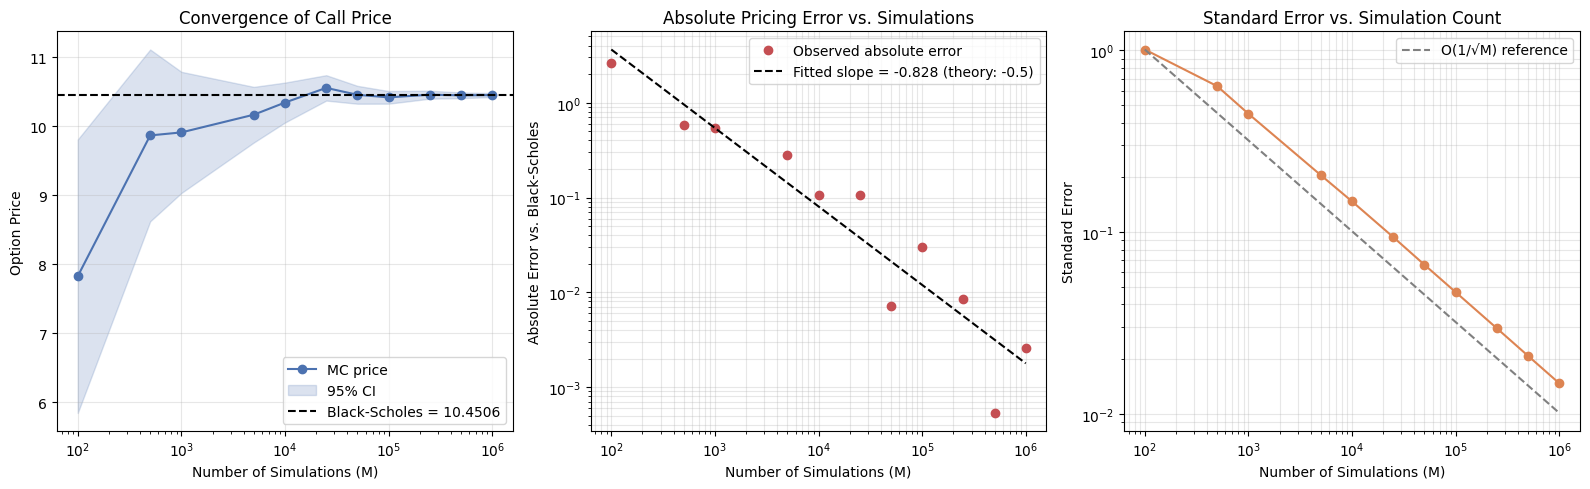

In [15]:
fig, axes = plot_convergence_panel(study, rate)
plt.show()


## 14. Put-Call Parity

```
C - P = S0 - K e^{-rT}
```

Black-Scholes satisfies this identity essentially exactly (floating
point only). Monte Carlo estimates satisfy it only up to the *combined*
sampling error of the two legs — the tolerance used below is set to a
small multiple of `SE_call + SE_put`, not to near-zero, precisely
because two independent Monte Carlo estimates won't cancel exactly.


In [16]:
bs_parity = check_put_call_parity(bs_call, bs_put, SPOT, STRIKE, RATE, MATURITY, tolerance=1e-8)
print("Black-Scholes parity:", bs_parity)

combined_se = call_result.standard_error + put_result.standard_error
mc_parity = check_put_call_parity(
    call_result.price, put_result.price, SPOT, STRIKE, RATE, MATURITY,
    tolerance=4 * combined_se,
)
print("Monte Carlo parity:  ", mc_parity)


Black-Scholes parity: Put-Call Parity: PASS (C-P=4.8771, S0-Ke^-rT=4.8771, error=0.0000, tolerance=0.0000)
Monte Carlo parity:   Put-Call Parity: PASS (C-P=4.8083, S0-Ke^-rT=4.8771, error=-0.0687, tolerance=0.2972)


## 15. No-Arbitrage Boundary Checks

In [17]:
call_bounds = check_call_bounds(call_result.price, SPOT, STRIKE, RATE, MATURITY)
put_bounds = check_put_bounds(put_result.price, SPOT, STRIKE, RATE, MATURITY)
print("Call bounds:", call_bounds)
print("Put bounds: ", put_bounds)


Call bounds: No-Arbitrage Bounds (CALL): PASS
Put bounds:  No-Arbitrage Bounds (PUT): PASS


## 16. Moneyness Analysis

Does Monte Carlo pricing error change with moneyness? Deep ITM/OTM
options have highly skewed payoff distributions (a huge point mass at
zero, or almost never at zero) — worth checking whether that affects
relative accuracy.


In [18]:
spot_grid = [50, 70, 90, 100, 110, 130, 150]
moneyness_points = sweep_parameter(call_option, "spot", spot_grid, sim_config)

labels, moneyness_vals, pct_errors = [], [], []
for p in moneyness_points:
    m = p.value / STRIKE
    opt_for_label = OptionParameters(p.value, STRIKE, RATE, VOL, MATURITY, OptionType.CALL)
    labels.append(f"S0={p.value:g}\n{opt_for_label.classify_moneyness()}")
    moneyness_vals.append(m)
    pct_errors.append(p.percentage_error)
    print(f"S0={p.value:>6.0f}  moneyness={m:.2f}  {opt_for_label.classify_moneyness():>9}  "
          f"MC={p.mc_price:8.4f}  BS={p.bs_price:8.4f}  %err={p.percentage_error:+7.3f}%")


S0=    50  moneyness=0.50   DEEP_OTM  MC=  0.0035  BS=  0.0024  %err=+44.316%
S0=    70  moneyness=0.70   DEEP_OTM  MC=  0.4533  BS=  0.4414  %err= +2.675%
S0=    90  moneyness=0.90        OTM  MC=  5.0928  BS=  5.0912  %err= +0.031%
S0=   100  moneyness=1.00        ATM  MC= 10.4205  BS= 10.4506  %err= -0.287%
S0=   110  moneyness=1.10        ITM  MC= 17.6168  BS= 17.6630  %err= -0.261%
S0=   130  moneyness=1.30   DEEP_ITM  MC= 35.3652  BS= 35.4403  %err= -0.212%
S0=   150  moneyness=1.50   DEEP_ITM  MC= 54.8719  BS= 54.9701  %err= -0.179%


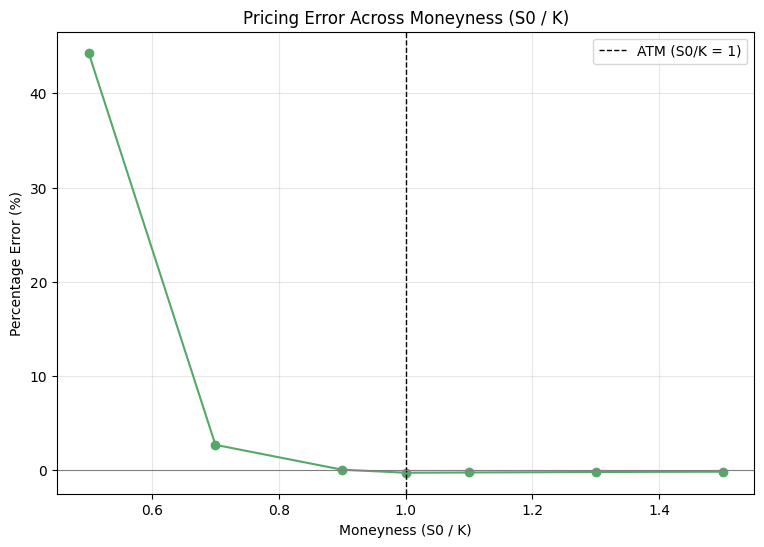

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_error_across_moneyness(moneyness_vals, pct_errors, ax=ax)
plt.show()


## 17. Parameter Sensitivity

Sweeping strike, volatility, rate, and maturity individually (holding
the rest at the benchmark scenario). This is **not** a Greeks engine —
it re-prices from scratch at each discrete value rather than computing
an analytical derivative — but it exercises the same pricing path
across a range of regimes, which is a useful sanity net before a future
Greeks module is added on top of `black_scholes.py`'s Greek-ready
`d1`/`d2` machinery.


In [20]:
vol_grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
vol_points = sweep_parameter(call_option, "volatility", vol_grid, sim_config)
for p in vol_points:
    print(f"sigma={p.value:.2f}  MC={p.mc_price:8.4f}  BS={p.bs_price:8.4f}  %err={p.percentage_error:+7.3f}%")


sigma=0.10  MC=  6.7844  BS=  6.8050  %err= -0.301%
sigma=0.15  MC=  8.5650  BS=  8.5917  %err= -0.310%
sigma=0.20  MC= 10.4205  BS= 10.4506  %err= -0.287%
sigma=0.25  MC= 12.3045  BS= 12.3360  %err= -0.256%
sigma=0.30  MC= 14.2016  BS= 14.2313  %err= -0.208%
sigma=0.40  MC= 18.0072  BS= 18.0230  %err= -0.087%


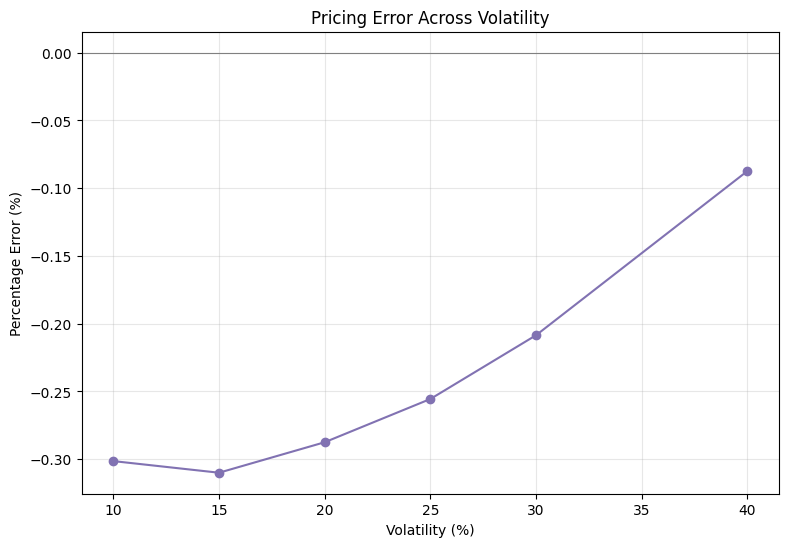

In [21]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_error_across_volatility(vol_grid, [p.percentage_error for p in vol_points], ax=ax)
plt.show()


In [22]:
rate_grid = [0.01, 0.03, 0.05, 0.07, 0.10]
maturity_grid = [0.1, 0.25, 0.5, 1, 2, 5]

rate_points = sweep_parameter(call_option, "risk_free_rate", rate_grid, sim_config)
maturity_points = sweep_parameter(call_option, "maturity", maturity_grid, sim_config)

print("Risk-free rate sweep:")
for p in rate_points:
    print(f"  r={p.value:.2f}  MC={p.mc_price:8.4f}  BS={p.bs_price:8.4f}  %err={p.percentage_error:+7.3f}%")

print("\nMaturity sweep:")
for p in maturity_points:
    print(f"  T={p.value:>4.2f}  MC={p.mc_price:8.4f}  BS={p.bs_price:8.4f}  %err={p.percentage_error:+7.3f}%")


Risk-free rate sweep:
  r=0.01  MC=  8.4148  BS=  8.4333  %err= -0.220%
  r=0.03  MC=  9.3875  BS=  9.4134  %err= -0.275%
  r=0.05  MC= 10.4205  BS= 10.4506  %err= -0.287%
  r=0.07  MC= 11.5079  BS= 11.5415  %err= -0.291%
  r=0.10  MC= 13.2332  BS= 13.2697  %err= -0.275%

Maturity sweep:
  T=0.10  MC=  2.7643  BS=  2.7737  %err= -0.336%
  T=0.25  MC=  4.6000  BS=  4.6150  %err= -0.325%
  T=0.50  MC=  6.8673  BS=  6.8887  %err= -0.311%
  T=1.00  MC= 10.4205  BS= 10.4506  %err= -0.287%
  T=2.00  MC= 16.0858  BS= 16.1268  %err= -0.254%
  T=5.00  MC= 29.0895  BS= 29.1386  %err= -0.168%


## 18. Visualization Roundup

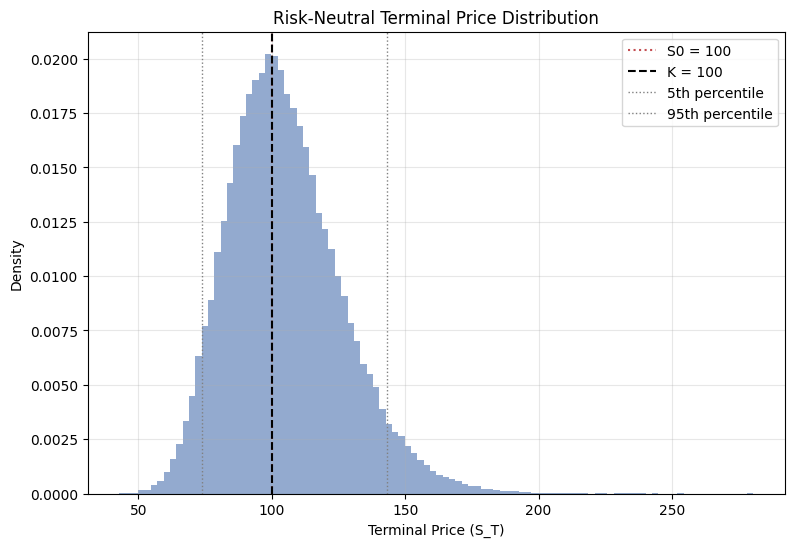

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_terminal_price_distribution(call_result.terminal_prices, SPOT, STRIKE, ax=ax)
plt.show()


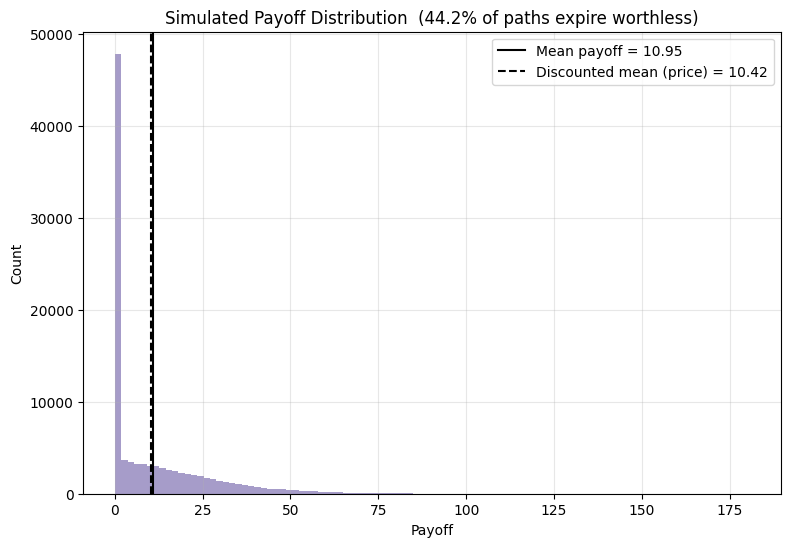

In [24]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_payoff_distribution(call_result.raw_payoffs, call_result.price, ax=ax)
plt.show()


The payoff distribution is highly asymmetric — a large spike at zero
(every path that expired out-of-the-money contributes exactly nothing)
plus a long right tail from in-the-money paths. This is very different
from the roughly bell-shaped log-normal terminal-*price* distribution
above it: the `max(·, 0)` in the payoff formula floors half or more of
the distribution at a single point, so the *average* payoff (which the
Monte Carlo price is built from) is pulled by a relatively thin set of
large-payoff paths — one reason OTM options can need more simulations
for the same relative precision as ATM options.


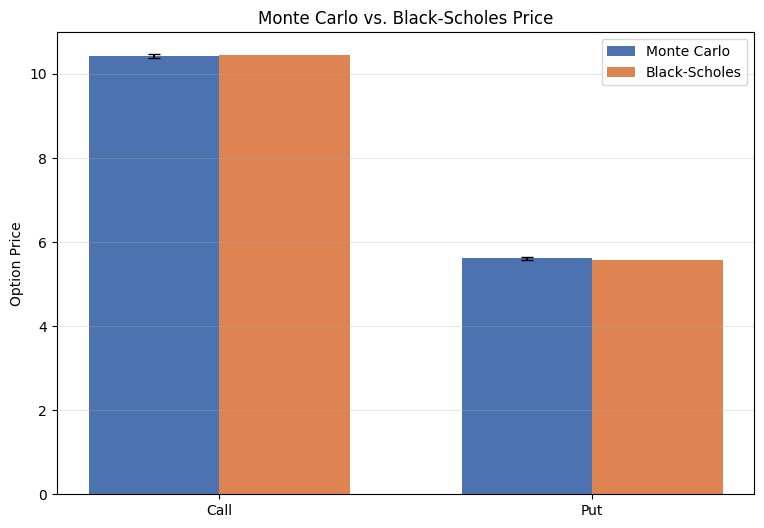

In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_mc_vs_bs_comparison(
    ["Call", "Put"],
    [call_result.price, put_result.price],
    [bs_call, bs_put],
    mc_errors=[call_result.standard_error, put_result.standard_error],
    ax=ax,
)
plt.show()


## 19. Full Validation Dashboard

In [26]:
dashboard = generate_paired_pricing_report(SPOT, STRIKE, RATE, VOL, MATURITY, sim_config)
print(dashboard)


European Option Pair — Pricing Dashboard (S0=100.0, K=100.0)
────────────────────────────────────────────────────────────

Market Inputs
Spot:                  $    100.00
Strike:                $    100.00
Risk-Free Rate:             5.00%
Volatility:                20.00%
Maturity:                    1.00 yr
Simulations:              100,000

Call
Monte Carlo Price:     $   10.4205
Black-Scholes Price:   $   10.4506
Percentage Error:         -0.2875%

Put
Monte Carlo Price:     $    5.6122
Black-Scholes Price:   $    5.5735
Percentage Error:          0.6940%

Validation
Put-Call Parity:       PASS
No-Arbitrage Bounds:   PASS
Convergence:           PASS


## 20. Conclusions

- Swapping the risk-neutral drift `r` in for the physical drift `μ` is
  the one change that separates Week 1's GBM engine from a genuine
  pricing engine — everything else (payoff → discount → average) is
  simple by comparison.
- Monte Carlo option prices converge to Black-Scholes at the classical
  `O(1/√M)` rate *in standard error*; the *realized* pricing error at any
  single `M` is noisier than that rate suggests, because it's one draw
  from a random process, not an ensemble average.
- Black-Scholes matching Monte Carlo (and vice versa) validates that
  **the implementation is internally consistent** — both target the same
  risk-neutral GBM price. It says nothing about whether GBM/Black-Scholes
  themselves describe real option markets accurately (they don't fully:
  volatility smiles, jumps, and stochastic volatility are all
  well-documented departures from this model in practice).
- The engine deliberately used **terminal-only** simulation throughout,
  since European payoffs depend only on `S_T`. Options whose payoff
  depends on the *path* — Asian (average price) or Barrier
  (knock-in/out) options — will need Week 1's full-path mode instead,
  which is why that mode was preserved rather than removed.
- `black_scholes.py` already computes `d1`/`d2` internally, which is
  exactly the building block a future Greeks module needs (Delta =
  `N(d1)` for a call, etc.) — that module is intentionally not built
  here, per this week's scope.

**Model limitations carried over from Black-Scholes/GBM** (see also the
Week 1 README section): constant volatility, no jumps, no regime
shifts, and no transaction costs or liquidity effects. These are
assumptions of the *model*, not bugs in this *implementation* — the
tests and sanity checks above validate the latter, not the former.
